### A Hebbian Learning Network

Part 1: Simulating the input data $\mathbf{x}$ and the target output $\mathbf{y}$

Part 2: Implementing Oja's Learning Rule

Part 3: Implementing Sanger's Rule

Part 4: Training the Network, and visualizing the Loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

### Model Structure

In [2]:
# Base model for classic Hebbian learning
class HebbianClassic(ABC):
    """
    Base class for linear Hebbian models.

    Conventions:
      - x: shape (n,), single sample (n = input_size)
      - W (self.weights): shape (n, k), columns are neuron weight vectors
      - y = x @ W  -> shape (k,)
    """
    def __init__(self, input_size, output_size, learning_rate=0.01, rng=None):
        if input_size <= 0 or output_size <= 0:
            raise ValueError("input_size and output_size must be positive integers.")
        self.input_size = int(input_size)
        self.output_size = int(output_size)
        self.learning_rate = float(learning_rate)
        self.rng = np.random.default_rng(rng)
        # small random init; columns are neurons
        self.weights = 0.01 * self.rng.standard_normal((self.input_size, self.output_size))


    def forward(self, x):
        """
        Purpose: Compute the output of the network y = W^T x
        x: shape (n,), online learning (one sample)
        returns y: shape (k,)
        """
        x = np.asarray(x, dtype=float).reshape(-1)
        if x.shape[0] != self.input_size:
            raise ValueError(f"x has shape {x.shape}, expected ({self.input_size},)")
        return x @ self.weights  # (k,)

    @abstractmethod
    def step(self, x):
        """
        Perform one online update with sample x. It is an abstract method, and should be implemented by the subclass.
        Must:
          - compute y = forward(x)
          - update self.weights in-place
          - return y (shape (k,))
        """
        raise NotImplementedError

    def train(self, X, epochs=1, shuffle=True):
        """
        Online training over X for 'epochs' passes.
        X: array-like of shape (N, n)
        """
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != self.input_size:
            raise ValueError(f"X has shape {X.shape}, expected (N, {self.input_size})")
        N = X.shape[0]
        for _ in range(int(epochs)):
                idx = np.arange(N)
                if shuffle:
                    self.rng.shuffle(idx)
                for t, i in enumerate(idx):
                    y = self.step(X[i])
                    
    # convenience
    @property
    def W(self):
        return self.weights

    def normalize_columns(self, epsilon=1e-12):
        """Optional: normalize each neuron to unit norm."""
        norms = np.linalg.norm(self.weights, axis=0, keepdims=True) + epsilon
        self.weights /= norms

    

### Oja's one neuron model

$$
\Delta w = \eta (yx - y^2 \mathbf{w})
$$


In [3]:
class Oja1(HebbianClassic):
    """
    Oja's rule for a single neuron (k = 1):
      w <- w + eta * ( y * x - y^2 * w ), where y = w^T x
    Learns the first principal component direction.
    """
    def __init__(self, input_size, learning_rate=0.01, rng=None):
        super().__init__(input_size=input_size, output_size=1,
                         learning_rate=learning_rate, rng=rng)

    def step(self, x):
      """
      Perform one online update with sample x. 
      Because it is a single neuron model, the calculation is based on the scalar y.
      """
      x = np.asarray(x, dtype=float).reshape(-1)
      y = float(self.forward(x))                # scalar
      # w is (n,), stored as column 0 of weights
      w = self.weights[:, 0]
      w += self.learning_rate * (y * x - (y * y) * w)
      self.weights[:, 0] = w
      return np.array([y])


### Oja's multi-neuron model
$$
\mathbf{x \in \mathbb{R}^n}
$$
$$
\mathbf{y = W^\top x \in \mathbb{R}^k}
$$
$$
\mathbf{x y^\top \in \mathbb{R}^{n \times k}}
$$
$$
\mathbf{W \in \mathbb{R}^{n \times k}}
$$
$$
\mathbf{yy^\top = \mathbb{R}^{k \times k}}
$$


In [4]:
class OjaNetwork(HebbianClassic):
    """
    Multi-output Oja "subspace rule":
      W <- W + eta * ( x y^T - W (y y^T) ),  y = W^T x
    Learns the PC subspace spanned by top-k PCs (order not enforced).
    """
    def step(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)           # (n,)
        y = self.forward(x)                                  # (k,)
        # ΔW = eta * ( x y^T - W (y y^T) )                   # x y^T is (n, k); W (y y^T) is (n, k)
        self.weights += self.learning_rate * (
            np.outer(x, y) - self.weights @ np.outer(y, y)
        )
        return y

### Sanger's multi-neuron model

$$
\mathbf{yy^\top = \begin{bmatrix}
    y_1 y_1 & y_1 y_2 & \cdots & y_1 y_k \\
    y_2 y_1 & y_2 y_2 & \cdots & y_2 y_k \\
    \vdots & \vdots & \ddots & \vdots \\
    y_k y_1 & y_k y_2 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{B = \begin{bmatrix}
    y_1 y_1 & y_1 y_2 & \cdots & y_1 y_k \\
    0 & y_2 y_2 & \cdots & y_2 y_k \\
    \vdots & \vdots & \ddots & \vdots \\
    0 & 0 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{\Delta W = \eta (x y^\top - W B)}
$$



In [5]:
class SangerNetwork(HebbianClassic):
    def __init__(self, input_size, output_size, learning_rate=0.01, rng=None):
        super().__init__(input_size, output_size, learning_rate, rng=rng)

    def step(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)
        y = self.forward(x)
        # ΔW = eta * (x y^T - w B), B is the upper triangular matrix of y y^T
        B = np.triu(np.outer(y, y))
        self.weights += self.learning_rate * (np.outer(x, y) - self.weights @ B)
        return y

### Training and testing: alignment to PCs

In [ ]:
def pca_topk(X, k, center=True):
    """
    PCA via SVD. Returns the top-k principal components.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data (each row is a sample).
    k : int
        Number of principal components to keep (1 <= k <= min
        (n_samples, n_features)).
    center : bool, default True
        If True, subtract column means before SVD.

    Returns
    -------
    pcs : ndarray, shape (n_features, k)
        Principal directions (each column is a PC vector).
    eigvals : ndarray, shape (k,)
        Eigenvalues (variances) along those PCs.
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    if not (1 <= k <= min(n, d)):
        raise ValueError(f"k must be in [1, {min(n, d)}], got {k}.")

    mean_ = X.mean(axis=0) if center else np.zeros(d)
    Xc = X - mean_ if center else X

    # SVD: Xc = U S Vt  (Vt rows are PCs)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    pcs = Vt[:k].T                    # (d, k)
    # Eigenvalues of covariance = S^2 / (n-1)
    eigvals_full = (S**2) / (n - 1 if n > 1 else 1)
    eigvals = eigvals_full[:k]

    return pcs, eigvals

def cosine_alignment(u, v):
    """|cos(theta)| between two vectors u, v."""
    u = u / (np.linalg.norm(u) + 1e-12)
    v = v / (np.linalg.norm(v) + 1e-12)
    return float(abs(u @ v))

def alignment_over_epochs(model, X, epochs, pcs, shuffle=True, match="best"):
    """
    Train 'model' for 'epochs' epochs, and record alignment to true PC1 after each epoch.

    Parameters
    ----------
    model : HebbianClassic (Oja1, OjaNetwork, or SangerNetwork)
    X     : (N, d) mean-centered data
    epochs: int
    pc    : list of (d,) unit vectors, the true PCs
    shuffle: bool
    match : 'first' or 'best'
        - 'first' : align PC1 with the model's first column (good for Sanger, which orders PCs)
        - 'best'  : pick the column with the highest |cos| to PC1 (good for Oja multi / unordered)

    Returns
    -------
    align_hist : list of floats, length = epochs
    """
    X = np.asarray(X, float)
    align_hist = []

    for _ in range(int(epochs)):
        model.train(X, epochs=1, shuffle=shuffle)  # one epoch at a time
        W = model.W                                # (d, k)
        if W.ndim == 1:
            w = W
            align_hist.append(cosine_alignment(w, pcs[0]))
        else:
            if match == "first":
                w = W[:, 0]
                align_hist.append(cosine_alignment(w, pcs[0]))
            elif match == "best":  # 'best'
                # choose the column most aligned with PC
                cols = W.shape[1]
                cands = [cosine_alignment(W[:, j], pcs[0]) for j in range(cols)]
                align_hist.append(max(cands))
            elif match == "all":
                # return two lists, one for each PC
                align_res = [cosine_alignment(W[:, i], pcs[i]) for i in range(len(pcs))]
                align_hist.append(align_res)
    return align_hist

#--------------------------------
# Visualization functions
#--------------------------------

def visualize_alignment(hist_list, label_list):
    for hist, label in zip(hist_list, label_list):
        plt.plot(hist, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Alignment to PC (|cos θ|)")
    plt.ylim(0, 1.01)
    plt.legend()
    plt.show()

def plot_samples_and_top2_pcs(X, center=True, scale=2.5, annotate=True, ax=None):
    """
    Visualize samples and the first two principal components (PCs).

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input samples (rows = samples).
    center : bool, default True
        Subtract column means before PCA.
    scale : float, default 2.5
        How long to draw PC arrows (in units of sqrt(eigenvalue)).
    annotate : bool, default True
        Whether to label the PC arrows with names and eigenvalues.
    ax : matplotlib Axes or None
        If provided, draw on this axes; otherwise create a new figure.

    Returns
    -------
    info : dict with keys:
        'pcs'     : (n_features, 2) first two principal directions (columns)
        'eigvals' : (2,) eigenvalues (variances) for PC1, PC2
        'mean'    : (n_features,) data mean used for centering
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape

    mean = X.mean(axis=0) if center else np.zeros(d)
    Xc = X - mean if center else X

    # PCA via SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    # PCs are columns of V = Vt.T; eigenvalues = S^2/(n-1)
    V = Vt.T
    eigvals_full = (S**2) / (n - 1 if n > 1 else 1)

    # order by descending variance
    order = np.argsort(eigvals_full)[::-1]
    V = V[:, order]
    eigvals = eigvals_full[order]

    # What to plot:
    if d == 2:
        # plot in original centered coordinates
        Xplot = Xc
        # PCs are already in data coordinates
        P = V[:, :2]                # (2,2)
        lam = eigvals[:2]
        origin = np.zeros(2)
        xlabel, ylabel = "x1 (centered)", "x2 (centered)"
    else:
        # project data to first two PCs (scores)
        P = V[:, :2]                # (d,2)
        lam = eigvals[:2]
        Xplot = Xc @ P              # (n,2)
        origin = np.zeros(2)
        xlabel, ylabel = "PC1 score", "PC2 score"

    # plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(Xplot[:, 0], Xplot[:, 1], s=10, alpha=0.6)
    ax.axhline(0, lw=0.6)
    ax.axvline(0, lw=0.6)

    # draw arrows for PC1 and PC2
    # length ∝ sqrt(eigenvalue); scaled by 'scale'
    if d == 2:
        # arrows in original coordinates
        for i in range(2):
            vec = scale * np.sqrt(lam[i]) * P[:, i]
            ax.arrow(origin[0], origin[1], vec[0], vec[1],
                     length_includes_head=True, head_width=0.05*np.linalg.norm(vec),
                     linewidth=2)
            if annotate:
                ax.text(vec[0]*1.05, vec[1]*1.05, f"PC{i+1}\nλ={lam[i]:.3f}")
    else:
        # In projected space, PCs are coordinate axes; draw aligned arrows
        for i in range(2):
            vec = np.zeros(2)
            vec[i] = scale * np.sqrt(lam[i])
            ax.arrow(origin[0], origin[1], vec[0], vec[1],
                     length_includes_head=True, head_width=0.05*np.linalg.norm(vec),
                     linewidth=2)
            if annotate:
                ax.text(vec[0]*1.05, vec[1]*1.05, f"PC{i+1}\nλ={lam[i]:.3f}")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title("Samples and top-2 PCs")

    return {"pcs": V[:, :2], "eigvals": eigvals[:2], "mean": mean}

### Test case 1: 2 neurons, 2 PCs

In [7]:
mu1 = 0.0
std1 = 1.0
mu2 = 0.0
std2 = 0.25
orientation = np.random.random() * np.pi
number_of_neurons = 2
number_of_samples = 500
learning_rate = 0.001
epochs = 500

In [17]:
def gauss_distrib(theta, mu1, std1, mu2, std2, number_of_samples):
    samples = np.zeros((number_of_samples, number_of_neurons));
    for i in range(number_of_samples):
        u1 = np.random.random();
        u2 = np.random.random();
        T1 = np.sqrt(-2 * np.log(u1)) * np.cos(2*np.pi*u2);
        T2 = np.sqrt(-2 * np.log(u1)) * np.sin(2*np.pi*u2);
        
        samples[i,0] = mu1 +  (std1*T1 * np.cos(theta) - std2*T2 * np.sin(theta));
        samples[i,1] = mu2 +  (std1*T1 * np.sin(theta) + std2*T2 * np.cos(theta));	
    return samples

# We precompute the samples
samples = gauss_distrib(orientation, mu1,std1,mu2,std2,number_of_samples)

samples[:,0] -= np.mean(samples[:,0])
samples[:,1] -=np.mean(samples[:,1])

In [9]:
X = samples
pcs, _ = pca_topk(X, 2, center=True)
pc1 = pcs[:,0]
pc2 = pcs[:,1]

oja1 = Oja1(input_size=X.shape[1], learning_rate=learning_rate, rng=0)
hist_oja1 = alignment_over_epochs(oja1, X, epochs=epochs, pcs = [pc1], shuffle=True, match="first")

ojaK = OjaNetwork(input_size=X.shape[1], output_size=2, learning_rate=learning_rate, rng=0)
hist_ojaK = alignment_over_epochs(ojaK, X, epochs=epochs, pcs = [pc1, pc2], shuffle=True, match="all")

sangerK = SangerNetwork(input_size=X.shape[1], output_size=2, learning_rate=learning_rate, rng=0)
hist_sanger2 = alignment_over_epochs(sangerK, X, epochs=epochs, pcs = [pc1, pc2], shuffle=True, match="all")

/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_32233/2473331869.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = float(self.forward(x))                # scalar


### Visualize the samples and PCs

{'pcs': array([[ 0.98053783,  0.19633023],
        [ 0.19633023, -0.98053783]]),
 'eigvals': array([1.09651981, 0.060363  ]),
 'mean': array([ 1.68753900e-17, -1.77635684e-18])}

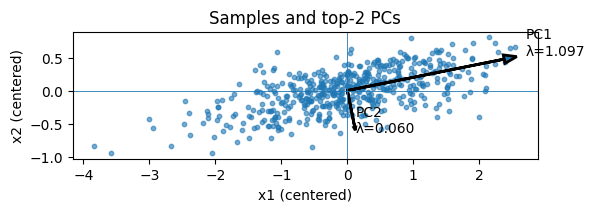

In [ ]:
plot_samples_and_top2_pcs(samples)

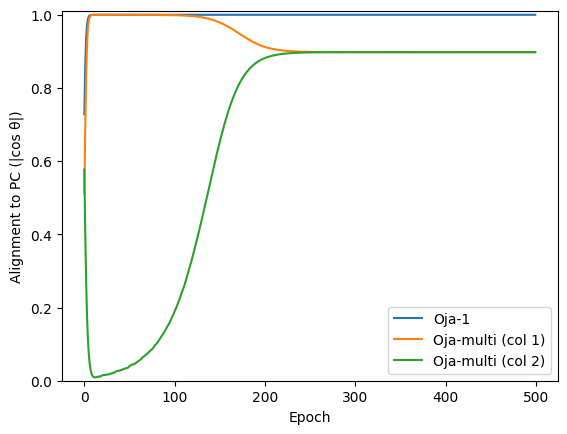

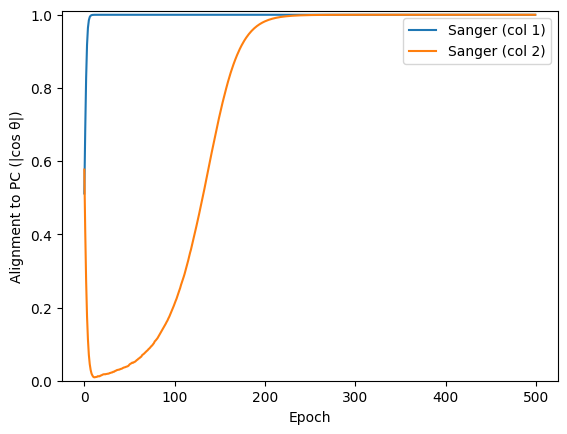

In [10]:
visualize_alignment([np.array(hist_oja1), np.array(hist_ojaK)[:,0], np.array(hist_ojaK)[:,1]], ["Oja-1", "Oja-multi (col 1)", "Oja-multi (col 2)"])
visualize_alignment([np.array(hist_sanger2)[:,0], np.array(hist_sanger2)[:,1]], ["Sanger (col 1)", "Sanger (col 2)"])

### Test case 2: 3 neurons, 3 PCs

In [11]:
mu = np.array([0.0, 0.0, 0.0])   # means for 3 neurons
cov = np.array([[1.0, 0.8, 0.3],   # covariance matrix (3x3, symmetric, PSD)
                [0.8, 0.5, 0.2],
                [0.3, 0.2, 0.3]])
samples = np.random.multivariate_normal(mu, cov, size=number_of_samples)

# Center the data (zero mean)
samples -= samples.mean(axis=0, keepdims=True)

print(samples.shape)   # (200, 3)

(500, 3)


/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_32233/242984893.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mu, cov, size=number_of_samples)


In [14]:
X = samples

# X is your data (N, d); IMPORTANT: center it first
# X = X - X.mean(axis=0, keepdims=True)

pcs, _ = pca_topk(X, 3, center=True)
pc1 = pcs[:,0]
pc2 = pcs[:,1]
pc3 = pcs[:,2]

# 1) Oja single-neuron
oja1 = Oja1(input_size=X.shape[1], learning_rate=learning_rate, rng=0)
hist_oja1 = alignment_over_epochs(oja1, X, epochs=epochs, pcs = [pc1], shuffle=True, match="first")

# 2) Oja multi-neuron
ojaK = OjaNetwork(input_size=X.shape[1], output_size=3, learning_rate=learning_rate, rng=0)
hist_ojaK = alignment_over_epochs(ojaK, X, epochs=epochs, pcs = [pc1, pc2, pc3], shuffle=True, match="all")

# 3) Sanger
sangerK = SangerNetwork(input_size=X.shape[1], output_size=3, learning_rate=learning_rate, rng=0)
hist_sanger2 = alignment_over_epochs(sangerK, X, epochs=epochs, pcs = [pc1, pc2, pc3], shuffle=True, match="all")

/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_32233/2473331869.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = float(self.forward(x))                # scalar


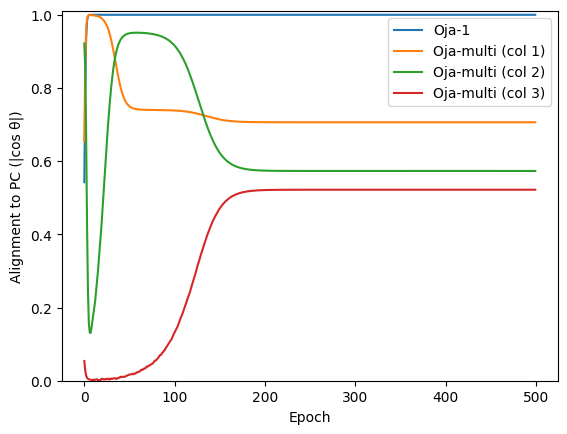

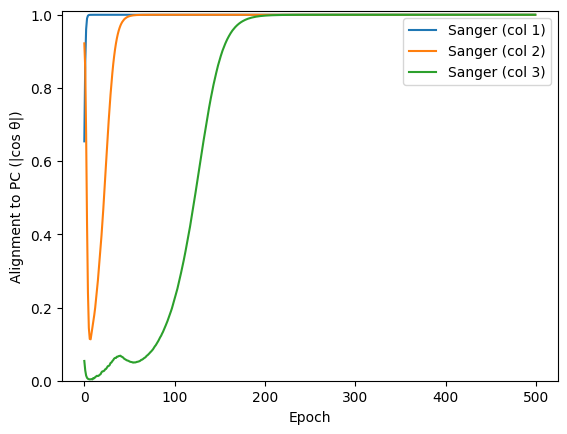

In [15]:
visualize_alignment([np.array(hist_oja1), np.array(hist_ojaK)[:,0], np.array(hist_ojaK)[:,1], np.array(hist_ojaK)[:,2]], ["Oja-1", "Oja-multi (col 1)", "Oja-multi (col 2)", "Oja-multi (col 3)"])
visualize_alignment([np.array(hist_sanger2)[:,0], np.array(hist_sanger2)[:,1], np.array(hist_sanger2)[:,2]], ["Sanger (col 1)", "Sanger (col 2)", "Sanger (col 3)"])